In [6]:
# Install necessary libraries
!pip install -U --pre tensorflow tensorflow-hub opencv-python matplotlib

# Import libraries
import tensorflow as tf
import tensorflow_hub as hub
import cv2
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")
print(f"TensorFlow Hub Version: {hub.__version__}")
print(f"OpenCV Version: {cv2.__version__}")

# Load the object detection model from TensorFlow Hub
# This URL points to a pre-trained SSD MobileNet V2 FPNLite 320x320 model
model_url = "https://tfhub.dev/tensorflow/ssd_mobilenet_v2/fpnlite_320x320/1"
detect_fn = hub.load(model_url)

print("Model loaded successfully!")

  Using cached tensorflow-2.21.0-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (4.4 kB)
  Using cached protobuf-7.34.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
TensorFlow Version: 2.19.1
TensorFlow Hub Version: 0.16.1
OpenCV Version: 4.13.0
Model loaded successfully!


In [40]:
# Using tf.keras.utils.get_file for a robust download of a reliable image containing cars
image_url = "https://tensorflow.org/images/grace_hopper.jpg"
image_path = tf.keras.utils.get_file(fname="grace_hopper.jpg", origin=image_url)

# Load the image using OpenCV
image_np = cv2.imread(image_path)

# Check if image was loaded successfully
if image_np is None:
    print(f"Error: Could not load image from {image_path}. Please check the path and file integrity.")
else:
    image_np = cv2.cvtColor(image_np, cv2.COLOR_BGR2RGB) # Convert BGR to RGB

    # The model expects a batch of images, so add a dimension
    input_tensor = tf.convert_to_tensor(image_np, dtype=tf.uint8)
    input_tensor = input_tensor[tf.newaxis, ...]

    # Perform inference
    detect_result = detect_fn(input_tensor)

    # Extract detection results
    # All output tensors are batch-major. We take the first element (index 0) to remove the batch dimension.
    num_detections = int(detect_result.pop('num_detections'))
    detect_result = {
        key: value[0, :num_detections].numpy()
        for key, value in detect_result.items()
    }
    detect_result['num_detections'] = num_detections

    # detection_classes should be ints.
    detect_result['detection_classes'] = detect_result['detection_classes'].astype(np.int64)

    def visualize_predictions(image, boxes, classes, scores, category_index, min_score_thresh=0.5):
        plt.figure(figsize=(10, 8))
        plt.imshow(image)
        ax = plt.gca()

        img_height, img_width, _ = image.shape

        for i in range(len(scores)):
            if scores[i] > min_score_thresh:
                ymin, xmin, ymax, xmax = boxes[i]
                (left, right, top, bottom) = (xmin * img_width, xmax * img_width,
                                              ymin * img_height, ymax * img_height)

                class_id = classes[i]
                class_name = category_index.get(class_id, {'name': 'N/A'})['name']
                score = scores[i]

                # Create a rectangle patch
                rect = plt.Rectangle((left, top), right - left, bottom - top,
                                     fill=False, edgecolor='red', linewidth=2)
                ax.add_patch(rect)

                # Add label and score
                label_text = f"{class_name}: {int(score*100)}%"
                ax.text(left, top - 10, label_text,
                        bbox=dict(facecolor='red', alpha=0.7),
                        fontsize=8, color='white')
        plt.axis('off')
        plt.show()

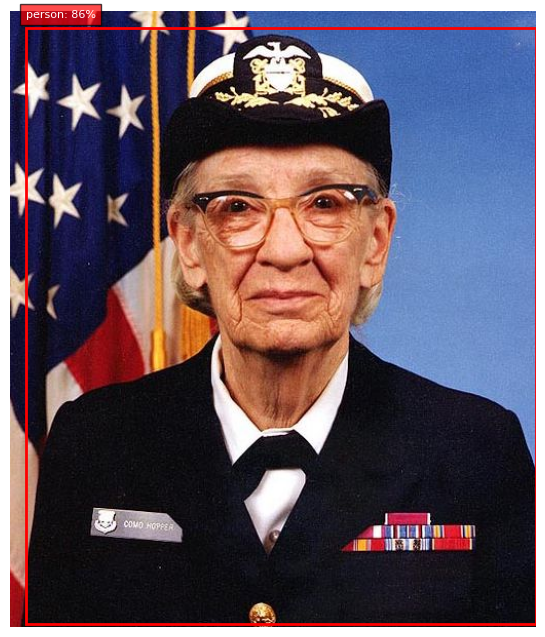

Inference complete!


In [42]:
# Placeholder for category_index (usually loaded from a label map file)
# For simplicity, we'll create a basic one. In a real scenario, you'd load
# COCO or other dataset's label map.
category_index = {
    1: {'id': 1, 'name': 'person'},
    2: {'id': 2, 'name': 'bicycle'},
    3: {'id': 3, 'name': 'car'},
    4: {'id': 4, 'name': 'motorcycle'},
    # Add more classes as needed based on the model's output
}

# Call the visualization function
visualize_predictions(
    image_np,
    detect_result['detection_boxes'],
    detect_result['detection_classes'],
    detect_result['detection_scores'],
    category_index
)


print("Inference complete!")